# Pretrain sequence encoder for K562

In this tutorial, we will train a sequence encoder to predict chromatin accessibility for K562 cells. This is similar to ChromBPNet and the idea is to learn sequence variation across the whole genome.

## Overview

The goal of this tutorial is to demonstrate how to:
1. **Prepare multiome single-cell data** from K562 cells containing both RNA and ATAC-seq measurements
2. **Train a deep learning model** that learns to predict chromatin accessibility patterns from DNA sequences
3. **Use the pretrained encoder** as a foundation for downstream cell2net modeling tasks

## Background

K562 is a widely-studied human erythroleukemic cell line that serves as an important model system in genomics research. By training a sequence encoder on K562 data, we can:

- Learn fundamental sequence-to-accessibility relationships
- Create reusable representations for regulatory sequence analysis  
- Establish a baseline model for comparing cell-type-specific effects
- Leverage transfer learning for other cell types and conditions

## What you'll learn

- How to load and explore multiome single-cell data using MuData
- Data preprocessing steps for sequence encoder training
- Model architecture and training procedures for genomic sequence prediction
- Evaluation metrics and visualization of model performance
- How to save and reuse the pretrained encoder for downstream applications

Let's get started!

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from scipy import stats
import torch
import cell2net as cn
import mudata as md
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

md.set_options(pull_on_update=False)

## Load and Explore Multiome Data

Let's start by loading the preprocessed K562 multiome single-cell data. This dataset contains paired RNA-seq and ATAC-seq measurements from the same cells, allowing us to study the relationship between gene expression and chromatin accessibility.

The data is stored in MuData format, which efficiently handles multimodal single-cell datasets with different feature spaces (genes for RNA, peaks for ATAC).

In [2]:
mdata = md.read_h5mu(
    "../../../../results/37_K562_10x_multiome/05_create_mdata/mdata.h5mu"
)

In [3]:
mdata

MuData object with n_obs × n_vars = 6508 × 151699
  obs:	'total_counts_rna', 'total_counts_atac', 'total_counts_rna_log', 'total_counts_atac_log'
  2 modalities
    rna:	6508 x 15735
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'DoubletScore', 'DoubletEnrichment', 'ReadsInPeaks', 'FRIP', 'nCount_ATAC', 'nFeature_ATAC', 'percent.mt', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
      var:	'genes', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns:	'hvg'
      obsm:	'X_pca', 'X_umap'
      layers:	'counts'
    atac:	6508 x 135964
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'DoubletScore', 'DoubletEnrichment', 'ReadsInPeaks', 'FRIP', 'nCount_ATAC', 'nFeature_ATAC', 'percent.mt', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
      var:	'peaks', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      obsm:	'X_umap'
      layers:	'counts'

Let's examine the structure of our multiome dataset. You can see it contains both RNA and ATAC modalities with their respective features and observations.

### Visualize Cell Embeddings

Let's visualize the UMAP embeddings for both RNA and ATAC modalities to understand the cellular heterogeneity in our K562 dataset.

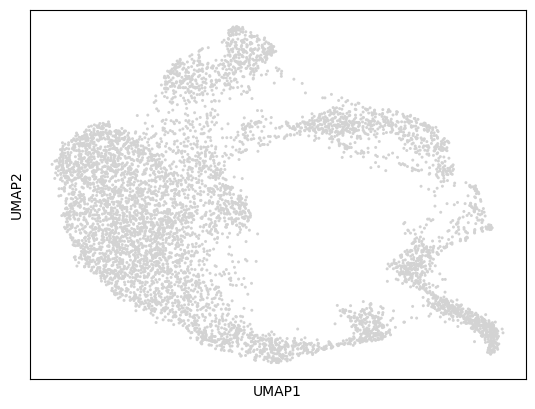

In [4]:
sc.pl.umap(mdata["rna"])

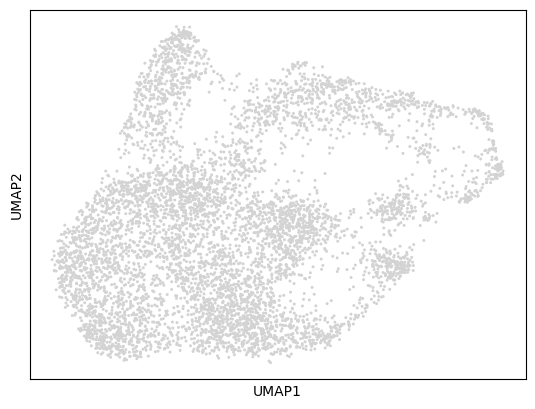

In [5]:
sc.pl.umap(mdata["atac"])

## Prepare Training Data for Sequence Encoder

Now we'll prepare the data for training our sequence encoder. This involves:

1. **Adding peak coordinates** with a fixed length (256bp) around peak summits
2. **Extracting DNA sequences** for each peak region from the reference genome
3. **Aggregating accessibility counts** across all cells for each peak

The goal is to create a dataset where we can learn to predict chromatin accessibility from DNA sequence alone.

In [6]:
cn.pp.add_peaks(mdata, mod_name='atac', peak_len=256)
cn.pp.add_dna_sequence(mdata, ref_fasta='../../../../data/refdata-gex-GRCh38-2020-A/fasta/genome.fa')


Fetching sequences:   0%|                                                                                                                                                                                  | 0/135964 [00:00<?, ?it/s]


Fetching sequences:  21%|██████████████████████████████████▌                                                                                                                               | 29025/135964 [00:00<00:00, 290173.48it/s]


Fetching sequences:  43%|█████████████████████████████████████████████████████████████████████▏                                                                                            | 58043/135964 [00:00<00:00, 264534.86it/s]


Fetching sequences:  62%|█████████████████████████████████████████████████████████████████████████████████████████████████████▏                                                            | 84882/135964 [00:00<00:00, 266202.17it/s]


Fetching sequences:  83%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                            | 112199/135964 [00:00<00:00, 268855.47it/s]


Fetching sequences: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 135964/135964 [00:00<00:00, 272801.89it/s]

### Aggregate Accessibility Scores

Here we aggregate the ATAC-seq counts across all cells to get a single accessibility score per peak. We use log1p transformation to normalize the highly skewed count distribution.

In [7]:
df_seq = mdata['atac'].uns['peaks']
df_true = mdata['atac'].layers['counts'].todense().sum(axis=0)
df_seq['acc'] = np.array(df_true).flatten()
df_seq['acc'] = np.log1p(df_seq['acc'])

Let's examine our prepared dataset. Each row represents a peak region with its DNA sequence and corresponding accessibility score.

In [8]:
df_seq.head()

,chr,start,end,summit,sequence,acc
chr1-812439-812939,chr1,812561,812817,812689,GATAAACATGGAAGCAACCCACATGTCCATCAGTGGATGAATAGAT...,5.802118
chr1-817080-817580,chr1,817202,817458,817330,GACAACCTACTGAATGAGAGAAACTATTTGCAAACTATGCATCTGA...,5.961005
chr1-819720-820220,chr1,819842,820098,819970,TTTCATTCTGAGTAGCTTGATGAAGTCTCATGCCGTCCCACTCAGC...,5.552959
chr1-820480-820980,chr1,820602,820858,820730,ACACTACCTGCTTGTCCAGCAGGTCCACACTGTCTACACTACCTGC...,5.442418
chr1-821021-821521,chr1,821143,821399,821271,CAGCTGATCCGCCCTGTCTACACTACCTGCTTGTCGAGCAGATCTG...,5.361292


### Split Data by Chromosome

To ensure proper evaluation, we split the data by chromosome rather than randomly. This prevents data leakage where the model might learn position-specific patterns rather than true sequence-to-accessibility relationships.

We use 80% of chromosomes for training and 20% for validation.

In [9]:
# split data into training and validation sets by chromosome
chromosomes = df_seq['chr'].unique().tolist()
np.random.seed(42)
np.random.shuffle(chromosomes)
split_idx = int(len(chromosomes) * 0.8)
train_chromosomes = chromosomes[:split_idx]
valid_chromosomes = chromosomes[split_idx:]

df_train = df_seq[df_seq['chr'].isin(train_chromosomes)]
df_valid = df_seq[df_seq['chr'].isin(valid_chromosomes)]

### Prepare Final Training DataFrames

We create clean training and validation dataframes with just the sequence and accessibility columns needed for model training.

In [10]:
df_train = df_train[['sequence', 'acc']].reset_index(drop=True)
df_valid = df_valid[['sequence', 'acc']].reset_index(drop=True)

### Examine Accessibility Score Distributions

Let's visualize the distribution of accessibility scores in our training and validation sets to ensure they're similarly distributed.

<Axes: xlabel='acc', ylabel='Count'>

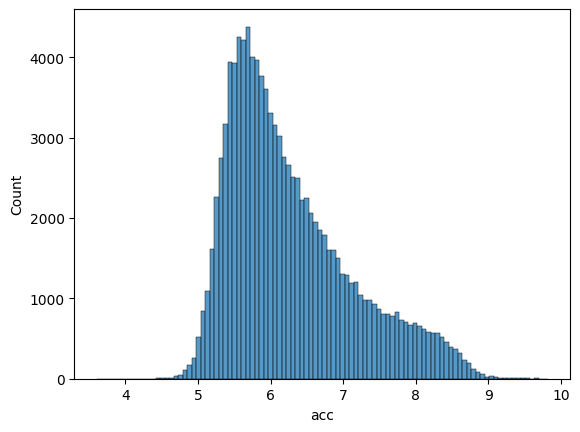

In [11]:
sns.histplot(df_train['acc'], bins=100)

<Axes: xlabel='acc', ylabel='Count'>

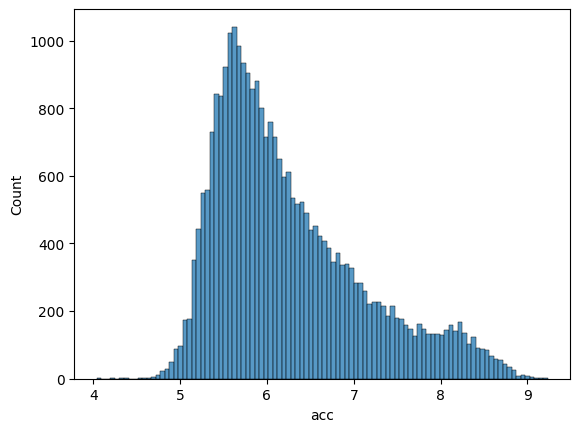

In [12]:
sns.histplot(df_valid['acc'], bins=100)

## Train the Sequence Encoder Model

Now we'll train our sequence-to-accessibility model using the cell2net framework. The `Seq2Acc` model uses a convolutional neural network to learn sequence patterns that predict chromatin accessibility.

In [13]:
model = cn.pd.model.Seq2Acc(peak_len=256, dropout_rate=0.25)

### Start Training

We train the model for up to 100 epochs with:
- **Batch size**: 512 sequences per batch
- **Learning rate**: 3e-4 with Adam optimizer
- **Weight decay**: 1e-4 for L2 regularization
- **Early stopping**: Based on validation loss to prevent overfitting

Training typically takes 1-2 minutes depending on your GPU.

In [14]:
model.train(df_train=df_train, df_valid=df_valid, max_epochs=100, 
            batch_size=512, weight_decay=1e-04, lr=3e-04)

2025-11-18 22:49:39 INFO     Creating dataloaders for training and validation


2025-11-18 22:49:54 INFO     Training peaks: 107414, Validation peaks: 28550


2025-11-18 22:49:55 INFO     Start training


2025-11-18 22:49:58 INFO     Epoch 0:, Train: 31.1594, Valid: 13.9208, Best: 13.9208


2025-11-18 22:50:00 INFO     Epoch 1:, Train: 5.5860, Valid: 0.8349, Best: 0.8349


...

2025-11-18 22:51:32 INFO     Epoch 40:, Train: 0.5332, Valid: 0.4225, Best: 0.4221


2025-11-18 22:51:34 INFO     Epoch 41:, Train: 0.5351, Valid: 0.4226, Best: 0.4221


2025-11-18 22:51:37 INFO     Epoch 42:, Train: 0.5311, Valid: 0.4226, Best: 0.4221


2025-11-18 22:51:39 INFO     Early stop!


2025-11-18 22:51:39 INFO     Training finished


### Save the Pretrained Model

We save the trained sequence encoder for reuse in downstream applications. This pretrained model can be loaded and used as a feature extractor for other cell2net models.

In [15]:
model.save_module('./pretrained_seq2acc.pth')

2025-11-18 22:51:39 INFO     Trained module saved to ./pretrained_seq2acc.pth


## Evaluate Model Performance

Now let's evaluate how well our trained model performs on both training and validation sets. We'll generate predictions and compare them to the true accessibility values.

In [16]:
# load best model weights
pretrained_state_dict = torch.load('./pretrained_seq2acc.pth')
model.module.seq_encoder.load_state_dict(pretrained_state_dict)

<All keys matched successfully>

In [17]:
df_train['pred_acc'] = model.predict(df_train)
df_valid['pred_acc'] = model.predict(df_valid)


Predicting:   0%|                                                                                                                                                                                             | 0/840 [00:00<?, ?it/s]


Predicting:   0%|▊                                                                                                                                                                                    | 4/840 [00:00<00:21, 39.21it/s]


Predicting:   6%|██████████▊                                                                                                                                                                        | 51/840 [00:00<00:02, 288.27it/s]


Predicting:  11%|███████████████████▊                                                                                                                                                               | 93/840 [00:00<00:02, 346.30it/s]


Predicting:  17%|██████████████████████████████                                                                                                                                                    | 142/840 [00:00<00:01, 400.85it/s]

...


Predicting:  52%|████████████████████████████████████████████████████████████████████████████████████████████▉                                                                                     | 117/224 [00:00<00:00, 285.63it/s]


Predicting:  68%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                                        | 153/224 [00:00<00:00, 309.52it/s]


Predicting:  85%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                           | 190/224 [00:00<00:00, 326.33it/s]


Predicting: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 224/224 [00:00<00:00, 317.36it/s]


Predicting: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 224/224 [00:00<00:00, 265.12it/s]

### Training Set Performance

Let's visualize the correlation between predicted and true accessibility scores on the training set. A good model should show strong correlation along the diagonal.

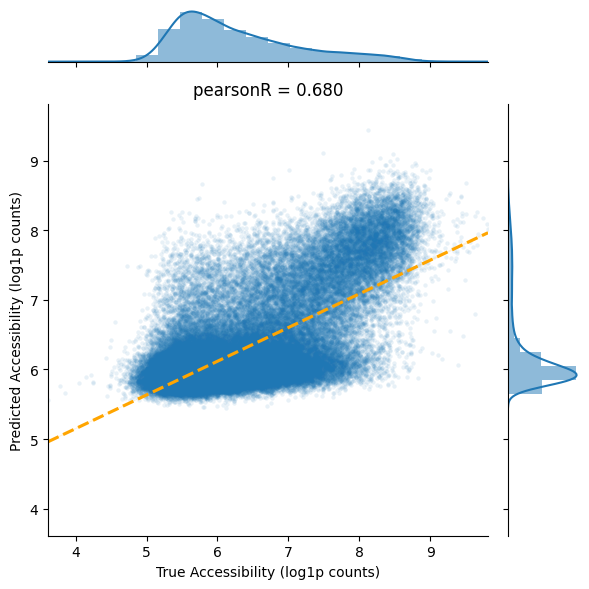

In [18]:
pearsonR, pv = stats.pearsonr(df_train['acc'], df_train['pred_acc'])

ax = sns.jointplot(
    data=df_train,
    x="acc",
    y="pred_acc",
    kind = 'scatter',
    joint_kws={'marker':'o', 's':10, 'alpha':0.1, 'linewidth':0},
    marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
)
ax.plot_joint(sns.regplot, color="r", scatter=False, 
              line_kws={"color": "orange", 'linestyle':'dashed'})
_min = np.min((np.min(df_train['acc'].values), np.min(df_train['pred_acc'].values)))
_max = np.max((np.max(df_train['acc'].values), np.max(df_train['pred_acc'].values)))

# set axis-x and axis-y the same scale
plt.xlim(_min, _max)
plt.ylim(_min, _max)
plt.title('pearsonR = {:.3f}'.format(pearsonR))
plt.xlabel('True Accessibility (log1p counts)')
plt.ylabel('Predicted Accessibility (log1p counts)')
plt.tight_layout()

### Validation Set Performance

More importantly, let's check the performance on the validation set (unseen chromosomes). This gives us a better sense of how well the model generalizes to new genomic regions.

The Pearson correlation coefficient provides a measure of linear relationship between predicted and true values. Values above 0.7 generally indicate good model performance for genomic applications.

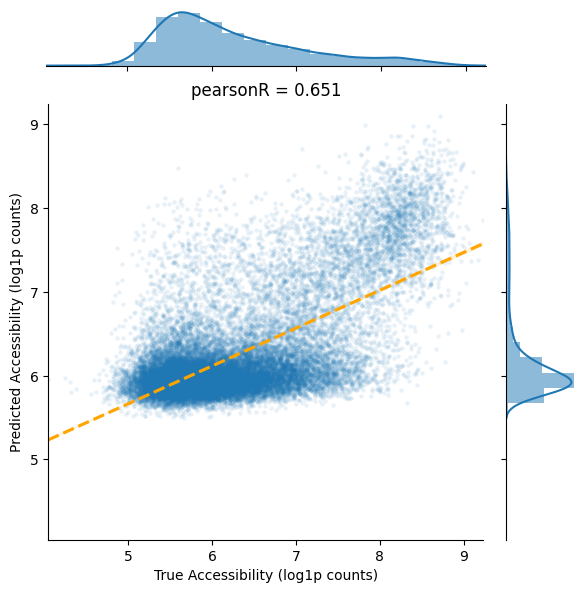

In [19]:
pearsonR, pv = stats.pearsonr(df_valid['acc'], df_valid['pred_acc'])

ax = sns.jointplot(
    data=df_valid,
    x="acc",
    y="pred_acc",
    kind = 'scatter',
    joint_kws={'marker':'o', 's':10, 'alpha':0.1, 'linewidth':0},
    marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
)
ax.plot_joint(sns.regplot, color="r", scatter=False, 
              line_kws={"color": "orange", 'linestyle':'dashed'})

_min = np.min((np.min(df_valid['acc'].values), np.min(df_valid['pred_acc'].values)))
_max = np.max((np.max(df_valid['acc'].values), np.max(df_valid['pred_acc'].values)))

# set axis-x and axis-y the same scale
plt.xlim(_min, _max)
plt.ylim(_min, _max)
plt.title('pearsonR = {:.3f}'.format(pearsonR))
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('True Accessibility (log1p counts)')
plt.ylabel('Predicted Accessibility (log1p counts)')
plt.tight_layout()

## Summary

Congratulations! You've successfully trained a sequence encoder that can predict chromatin accessibility from DNA sequence alone. Here's what we accomplished:

### Key Results
- **Model Architecture**: Convolutional neural network for sequence-to-accessibility prediction
- **Training Strategy**: Chromosome-wise data splitting to ensure proper generalization
- **Performance Metrics**: Pearson correlation on validation set indicates model quality
- **Reusable Asset**: Saved pretrained encoder for downstream applications

### Next Steps

This pretrained sequence encoder can now be used in several ways:

1. **Feature Extraction**: Use the encoder to generate sequence embeddings for other models
2. **Transfer Learning**: Fine-tune the encoder for different cell types or conditions  
3. **Interpretation**: Analyze learned sequence motifs and patterns
4. **Integration**: Incorporate into cell2net models for joint RNA-ATAC analysis

The model learns fundamental sequence-accessibility relationships that are transferable across different experimental contexts, making it a valuable foundation for genomic deep learning applications.